In [18]:
from mymodels import squeezenet1_1, train, kCV, test_error
from dataUtils import *
from sklearn.model_selection import KFold
from torch.utils.data import Subset
from torch import nn,optim,save,load
import matplotlib.pyplot as plt
import time
from torch.cuda import synchronize
import matplotlib
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
%matplotlib inline

device = 'cuda'

In [3]:
model = squeezenet1_1(dropout=0)
model.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.02848174232146005)
epochs = 15
dataset = make_train_val_set()
all_loss = kCV(5,dataset,model,loss_fn,optimizer,epochs=epochs,batch_size=32)
save(model.state_dict(), 'models/squeeze_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.0429951615099396
	val. loss:	 0.04246930629014969
EPOCH 2
	train loss:	 0.04013735116744528
	val. loss:	 0.042102716863155365
EPOCH 3
	train loss:	 0.039021685405881426
	val. loss:	 0.04263633497059345
EPOCH 4
	train loss:	 0.03722193697467446
	val. loss:	 0.03793870665132999
EPOCH 5
	train loss:	 0.03682518766584749
	val. loss:	 0.03892741195857525
EPOCH 6
	train loss:	 0.03677525339477068
	val. loss:	 0.03938636064529419
EPOCH 7
	train loss:	 0.035877381261362105
	val. loss:	 0.04073808699846268
EPOCH 8
	train loss:	 0.036394948767003964
	val. loss:	 0.037138820588588715
EPOCH 9
	train loss:	 0.03680317473540805
	val. loss:	 0.03819553755223751
EPOCH 10
	train loss:	 0.03653915864130368
	val. loss:	 0.0391829813271761
EPOCH 11
	train loss:	 0.037179269428764074
	val. loss:	 0.03784939728677273
EPOCH 12
	train loss:	 0.03738824319930709
	val. loss:	 0.038390368819236756
EPOCH 13
	train loss:	 0.03626122221122591
	val. loss:	 0.03839071251451969
EPOCH 14


In [4]:
import json
filename = 'results/squeezenet.json'
with open(filename, 'w') as fp:
        json.dump(all_loss, fp)

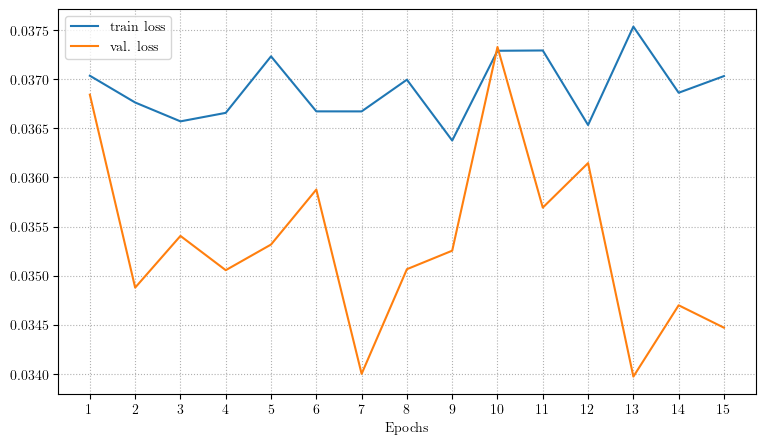

In [28]:
net = squeezenet1_1()
net.load_state_dict(load('models/squeeze_net.pth',weights_only=True))
all_loss = load_json('results/squeezenet.json')
plt.subplots(figsize=(9,5))
epochs = len(all_loss['all-loss'][0]['train'])
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['train'],label='train loss')
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['validation'],label='val. loss')
plt.xticks(range(1,epochs+1))
plt.legend()
plt.xlabel('Epochs')
plt.grid(linestyle='dotted')
plt.savefig('squeezenet_loss.pdf',bbox_inches='tight', pad_inches=0)

In [3]:
cv = all_loss['CV-loss']
test = test_error(net,make_test_set())
validation = all_loss['all-loss'][-1]['validation'][-1]
train = all_loss['all-loss'][-1]['train'][-1]

print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.03703076214225469
valid.: 0.034470676258206365
test: 0.0384948955535696
cv: 0.03681971260160207


In [13]:
testloader = DataLoader(
    make_test_set(), batch_size=4, shuffle=False, num_workers=2
)
net.eval()
total_time = 0
device = 'cuda'
net.to(device)
test_error(net,make_test_set(),device='cuda') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time GPU: {inf_time}')
total_time = 0
device = 'cpu'
net.to(device)
test_error(net,make_test_set(),device='cpu') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time CPU: {inf_time}')

inference time GPU: 0.0003311548424863267
inference time CPU: 0.0038984284318726637


In [14]:
param_size = 0
for param in net.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in net.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 2.761MB
